# Mean-Pooling Experiment Summary (Presentation Figures)

This notebook builds presentation-ready summary figures for mean-pooled embeddings across:

- `agreement_pivot`
- `distinct_names`
- `quote_intrusion`
- `similar_neutral`
- `similar_polarize`

Outputs are saved to:

- `speaker-tracking/data/experiments/mean_pooling/plots/presentation_summary_v1`

Figures:

1. Geometry scorecard across experiments
2. Linear probe selectivity summary
3. Turnwise role-projection trajectories aggregated across transcripts
4. Transcript-level distributions

In [8]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["axes.titleweight"] = "bold"


def resolve_repo_root(start: Path) -> Path:
    """Find repo root regardless of notebook launch directory."""
    cur = start.resolve()
    for candidate in [cur, *cur.parents]:
        if (candidate / ".git").exists() and (candidate / "speaker-tracking").exists():
            return candidate
    raise RuntimeError(
        f"Could not locate repo root from {start}. "
        "Run this notebook from inside the role-representation repository."
    )


REPO_ROOT = resolve_repo_root(Path.cwd())
ANALYSIS_DIR = REPO_ROOT / "speaker-tracking/data/experiments/mean_pooling/analysis"
EMBED_CKPT_DIR = REPO_ROOT / "speaker-tracking/data/experiments/mean_pooling/embeddings"
OUT_DIR = REPO_ROOT / "speaker-tracking/data/experiments/mean_pooling/plots/presentation_summary_v1"
OUT_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_ORDER = [
    "agreement_pivot",
    "distinct_names",
    "quote_intrusion",
    "similar_neutral",
    "similar_polarize",
]

DISPLAY_NAME = {
    "agreement_pivot": "Agreement Pivot",
    "distinct_names": "Distinct Names",
    "quote_intrusion": "Quote Intrusion",
    "similar_neutral": "Similar Neutral",
    "similar_polarize": "Similar Polarize",
}

print(f"Repo root: {REPO_ROOT}")
print(f"Analysis dir: {ANALYSIS_DIR}")
print(f"Embedding ckpt dir: {EMBED_CKPT_DIR}")
print(f"Output dir: {OUT_DIR}")

Repo root: /Users/jessebafernando/Dropbox/My Mac (Jesseba’s MacBook Pro)/Documents/GitHub/role-representation
Analysis dir: /Users/jessebafernando/Dropbox/My Mac (Jesseba’s MacBook Pro)/Documents/GitHub/role-representation/speaker-tracking/data/experiments/mean_pooling/analysis
Embedding ckpt dir: /Users/jessebafernando/Dropbox/My Mac (Jesseba’s MacBook Pro)/Documents/GitHub/role-representation/speaker-tracking/data/experiments/mean_pooling/embeddings
Output dir: /Users/jessebafernando/Dropbox/My Mac (Jesseba’s MacBook Pro)/Documents/GitHub/role-representation/speaker-tracking/data/experiments/mean_pooling/plots/presentation_summary_v1


In [9]:
def load_geometry_summary(analysis_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    global_rows = []
    transcript_rows = []

    for exp in EXPERIMENT_ORDER:
        fp = analysis_dir / f"exp_{exp}_geometry.json"
        with fp.open("r", encoding="utf-8") as f:
            payload = json.load(f)

        model_blob = next(iter(payload["results_by_model"].values()))
        metrics = model_blob["metrics"]
        global_rows.append({"experiment": exp, **metrics})

        for tid, vals in model_blob.get("per_transcript_metrics", {}).items():
            transcript_rows.append({"experiment": exp, "transcript_id": tid, **vals})

    return pd.DataFrame(global_rows), pd.DataFrame(transcript_rows)


def _extract_probe_metric(task_blob: dict, metric: str = "accuracy") -> dict:
    out = {}
    for probe_name in ("logreg_l2", "linear_svm"):
        out[f"{probe_name}_mean"] = task_blob["aggregate"][probe_name][metric]["mean"]
        out[f"{probe_name}_std"] = task_blob["aggregate"][probe_name][metric]["std"]

        if "aggregate_control" in task_blob:
            out[f"{probe_name}_control_mean"] = task_blob["aggregate_control"][probe_name][metric]["mean"]
        if "aggregate_selectivity" in task_blob:
            out[f"{probe_name}_selectivity_mean"] = task_blob["aggregate_selectivity"][probe_name][metric]["mean"]
    return out


def load_probe_summary(analysis_dir: Path) -> pd.DataFrame:
    rows = []
    for exp in EXPERIMENT_ORDER:
        fp = analysis_dir / f"exp_{exp}_linear_probe.json"
        with fp.open("r", encoding="utf-8") as f:
            payload = json.load(f)

        model_blob = next(iter(payload["results_by_model"].values()))

        for task_name in ("role", "variant"):
            task_blob = model_blob.get(task_name)
            if not task_blob:
                continue
            row = {
                "experiment": exp,
                "task": task_name,
                "num_rows": task_blob.get("num_rows"),
                "num_groups": task_blob.get("num_groups"),
            }
            row.update(_extract_probe_metric(task_blob, metric="accuracy"))
            rows.append(row)

    return pd.DataFrame(rows)


geom_df, geom_tx_df = load_geometry_summary(ANALYSIS_DIR)
probe_df = load_probe_summary(ANALYSIS_DIR)

geom_df.head(), probe_df.head()

(         experiment  num_rows  num_base_rows  between_role_centroid_distance  \
 0   agreement_pivot      4800           2400                        0.726981   
 1    distinct_names      4800           2400                        0.327531   
 2   quote_intrusion      4800           2400                        0.438076   
 3   similar_neutral      4800           2400                        0.406722   
 4  similar_polarize      4800           2400                        0.778734   
 
    within_role_dispersion_alice  within_role_dispersion_bob  \
 0                      5.895412                    5.834529   
 1                      7.025660                    6.995837   
 2                      7.104593                    6.959989   
 3                      6.509377                    6.547721   
 4                      5.917361                    5.887570   
 
    distance_over_dispersion  silhouette_role_base_only  \
 0                  0.123953                   0.003392   
 1      

/var/folders/qq/vh114g916ydccg5ydgm445n40000gn/T/ipykernel_34140/750149915.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([DISPLAY_NAME[e] for e in geom_plot["experiment"]], rotation=25, ha="right")
/var/folders/qq/vh114g916ydccg5ydgm445n40000gn/T/ipykernel_34140/750149915.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels([DISPLAY_NAME[e] for e in geom_plot["experiment"]], rotation=25, ha="right")
/var/folders/qq/vh114g916ydccg5ydgm445n40000gn/T/ipykernel_34140/750149915.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels([DISPLAY_NAME[e] for e in geom_plot["experiment"]], rotation=25, ha="right")


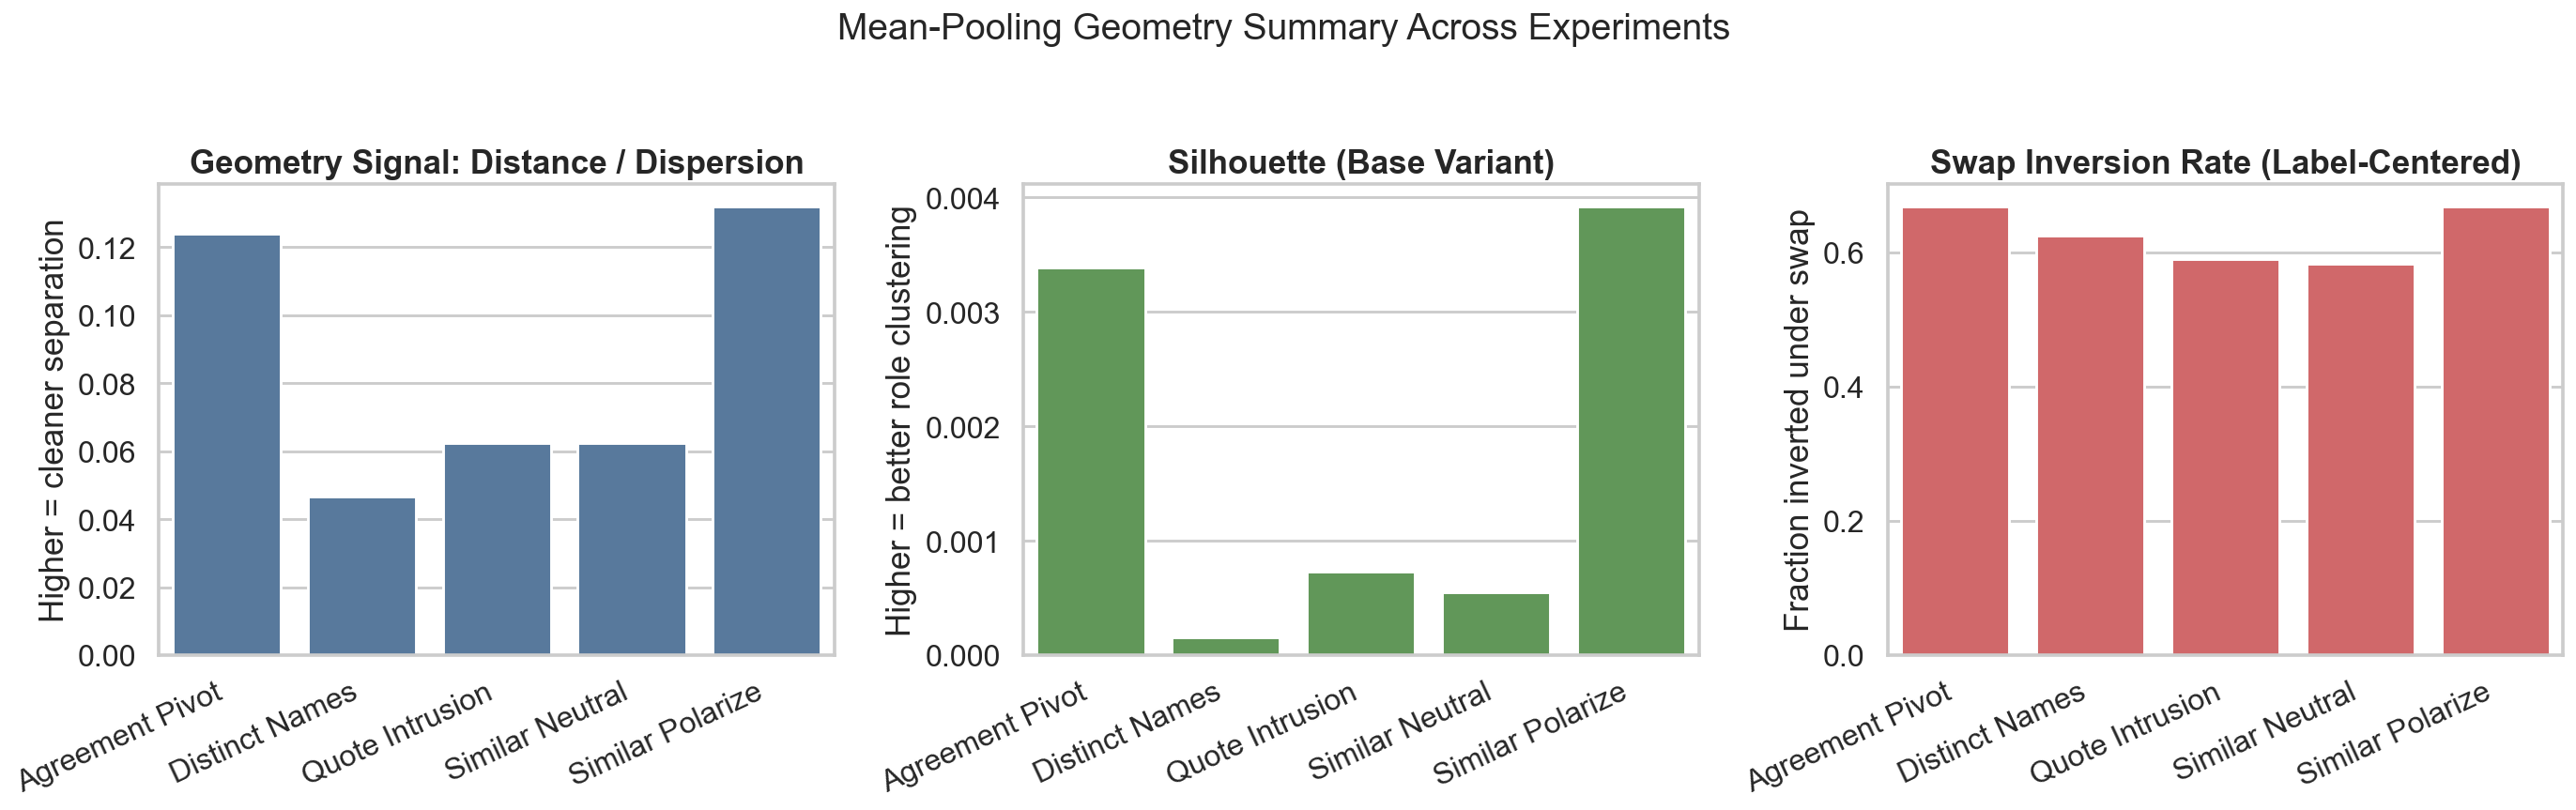

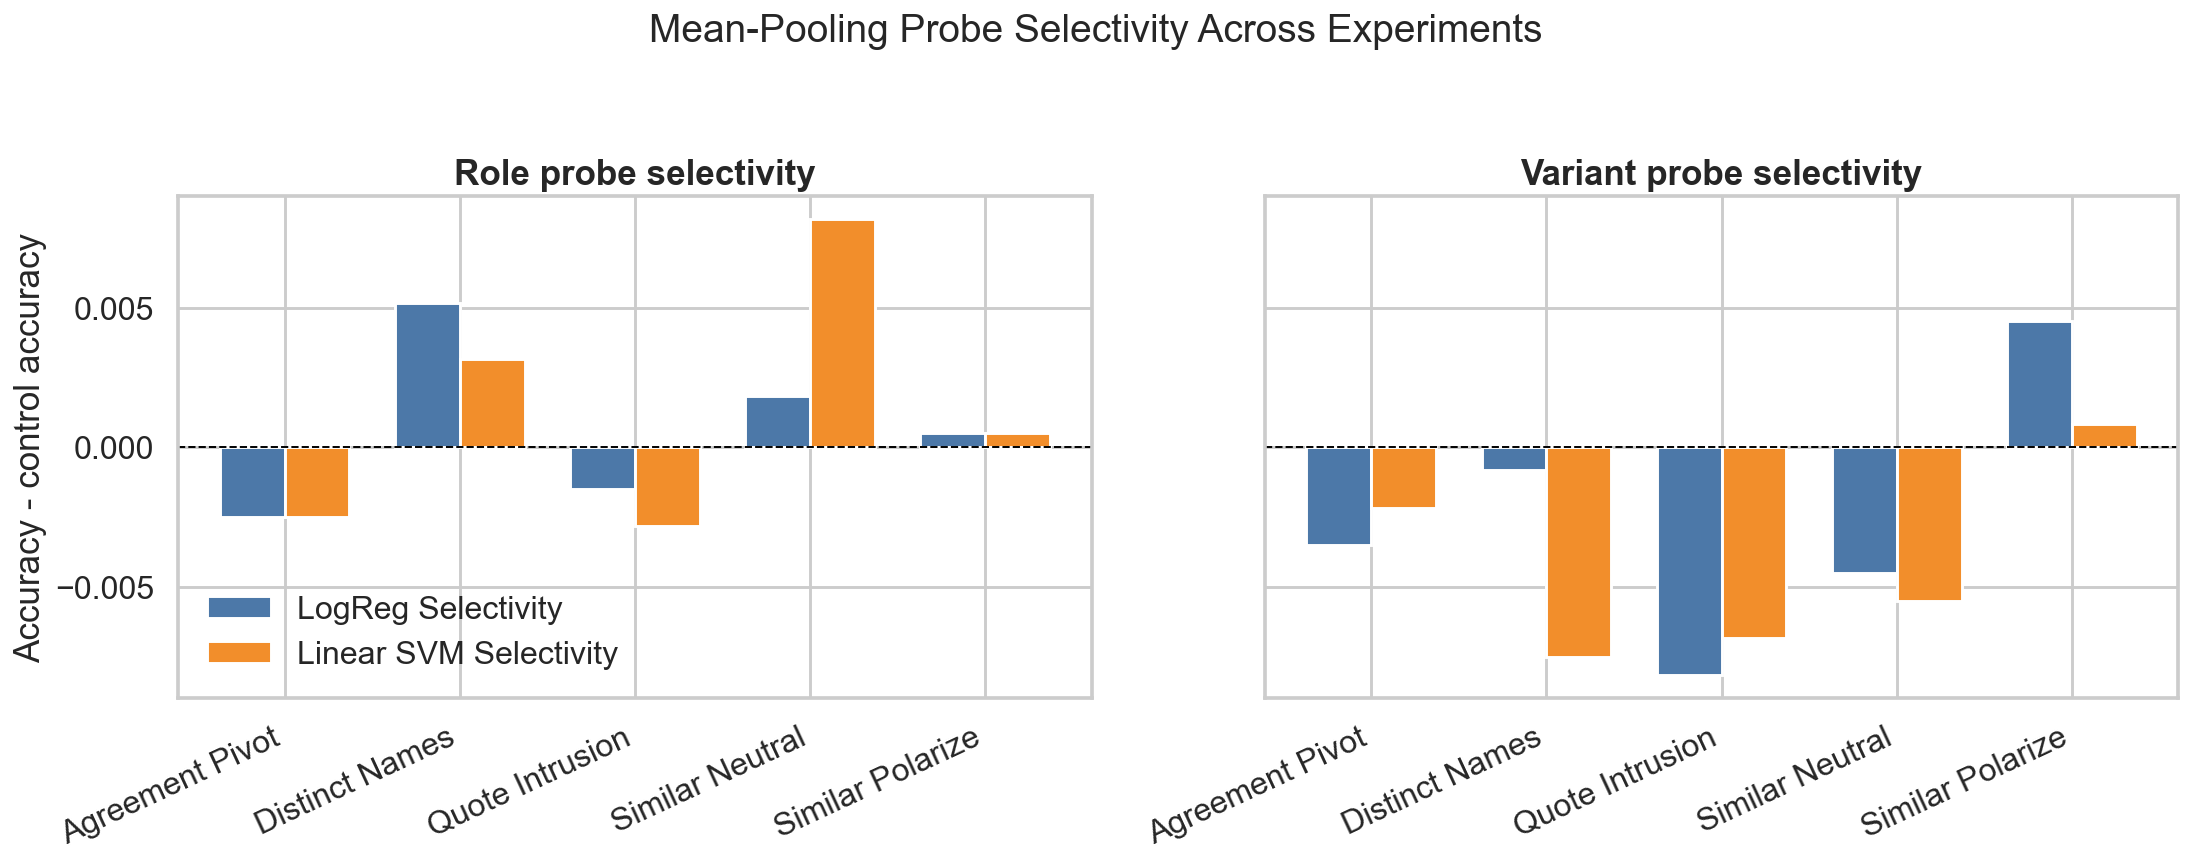

In [10]:
geom_plot = geom_df.copy()
geom_plot["experiment_label"] = geom_plot["experiment"].map(DISPLAY_NAME)
geom_plot = geom_plot.set_index("experiment").loc[EXPERIMENT_ORDER].reset_index()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(
    data=geom_plot,
    x="experiment",
    y="distance_over_dispersion",
    color="#4C78A8",
    ax=axes[0],
)
axes[0].set_title("Geometry Signal: Distance / Dispersion")
axes[0].set_xlabel("")
axes[0].set_ylabel("Higher = cleaner separation")
axes[0].set_xticklabels([DISPLAY_NAME[e] for e in geom_plot["experiment"]], rotation=25, ha="right")

sns.barplot(
    data=geom_plot,
    x="experiment",
    y="silhouette_role_base_only",
    color="#59A14F",
    ax=axes[1],
)
axes[1].axhline(0.0, ls="--", lw=1, color="black")
axes[1].set_title("Silhouette (Base Variant)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Higher = better role clustering")
axes[1].set_xticklabels([DISPLAY_NAME[e] for e in geom_plot["experiment"]], rotation=25, ha="right")

sns.barplot(
    data=geom_plot,
    x="experiment",
    y="swap_projection_inversion_rate_label_centered",
    color="#E15759",
    ax=axes[2],
)
axes[2].set_title("Swap Inversion Rate (Label-Centered)")
axes[2].set_xlabel("")
axes[2].set_ylabel("Fraction inverted under swap")
axes[2].set_xticklabels([DISPLAY_NAME[e] for e in geom_plot["experiment"]], rotation=25, ha="right")

fig.suptitle("Mean-Pooling Geometry Summary Across Experiments", y=1.04, fontsize=20)
fig.tight_layout()
fig.savefig(OUT_DIR / "figure1_geometry_scorecard.png", bbox_inches="tight")
fig.savefig(OUT_DIR / "figure1_geometry_scorecard.pdf", bbox_inches="tight")
plt.show()


probe_plot = probe_df.copy()
probe_plot["experiment"] = pd.Categorical(probe_plot["experiment"], categories=EXPERIMENT_ORDER, ordered=True)
probe_plot = probe_plot.sort_values(["task", "experiment"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, task_name in zip(axes, ["role", "variant"]):
    block = probe_plot[probe_plot["task"] == task_name].copy()
    block["experiment_label"] = block["experiment"].map(DISPLAY_NAME)

    x = np.arange(len(block))
    width = 0.37

    ax.bar(
        x - width/2,
        block["logreg_l2_selectivity_mean"],
        width,
        label="LogReg Selectivity",
        color="#4C78A8",
    )
    ax.bar(
        x + width/2,
        block["linear_svm_selectivity_mean"],
        width,
        label="Linear SVM Selectivity",
        color="#F28E2B",
    )
    ax.axhline(0.0, ls="--", lw=1, color="black")
    ax.set_title(f"{task_name.capitalize()} probe selectivity")
    ax.set_xticks(x)
    ax.set_xticklabels(block["experiment_label"], rotation=25, ha="right")
    ax.set_xlabel("")

axes[0].set_ylabel("Accuracy - control accuracy")
axes[0].legend(frameon=False)
fig.suptitle("Mean-Pooling Probe Selectivity Across Experiments", y=1.04, fontsize=20)
fig.tight_layout()
fig.savefig(OUT_DIR / "figure2_probe_selectivity.png", bbox_inches="tight")
fig.savefig(OUT_DIR / "figure2_probe_selectivity.pdf", bbox_inches="tight")
plt.show()

In [11]:
def load_embedding_ckpt_rows(fp: Path, variant: str = "base") -> list[dict]:
    rows: list[dict] = []
    with fp.open("r", encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            if obj.get("variant") != variant:
                continue
            rows.append(obj)
    return rows


def build_projection_table(rows: list[dict], experiment: str) -> pd.DataFrame:
    records = []

    # Group rows per transcript for transcript-local centering and role direction.
    by_tid: dict[str, list[dict]] = {}
    for r in rows:
        by_tid.setdefault(r["transcript_id"], []).append(r)

    for tid, rlist in by_tid.items():
        alice_vecs = [np.array(r["vector"], dtype=np.float32) for r in rlist if r["speaker"] == "Alice"]
        bob_vecs = [np.array(r["vector"], dtype=np.float32) for r in rlist if r["speaker"] == "Bob"]
        if not alice_vecs or not bob_vecs:
            continue

        alice_cent = np.mean(np.stack(alice_vecs, axis=0), axis=0)
        bob_cent = np.mean(np.stack(bob_vecs, axis=0), axis=0)
        direction = alice_cent - bob_cent
        norm = float(np.linalg.norm(direction))
        if norm < 1e-8:
            continue

        unit_dir = direction / norm
        midpoint = 0.5 * (alice_cent + bob_cent)
        max_turn = max(int(r["turn_id"]) for r in rlist)

        for r in rlist:
            vec = np.array(r["vector"], dtype=np.float32)
            projection = float(np.dot(vec - midpoint, unit_dir))
            records.append(
                {
                    "experiment": experiment,
                    "transcript_id": tid,
                    "speaker": r["speaker"],
                    "turn_id": int(r["turn_id"]),
                    "turn_frac": int(r["turn_id"]) / max(1, max_turn),
                    "projection": projection,
                }
            )

    df = pd.DataFrame(records)
    # Transcript-local z score makes cross-transcript aggregation more stable.
    df["projection_z"] = (
        df.groupby(["experiment", "transcript_id"])["projection"]
          .transform(lambda s: (s - s.mean()) / (s.std(ddof=0) + 1e-8))
    )
    return df


projection_tables = []
for exp in EXPERIMENT_ORDER:
    fp = EMBED_CKPT_DIR / f"exp_{exp}_mean_embeddings.ckpt.jsonl"
    rows = load_embedding_ckpt_rows(fp, variant="base")
    projection_tables.append(build_projection_table(rows, exp))

proj_df = pd.concat(projection_tables, ignore_index=True)
proj_df["turn_bin"] = np.clip((proj_df["turn_frac"] * 20).astype(int), 0, 19)
proj_df.head()

,experiment,transcript_id,speaker,turn_id,turn_frac,projection,projection_z,turn_bin
0,agreement_pivot,agreement_pivot_000,Alice,0,0.000000,2.768386,2.638888,0
1,agreement_pivot,agreement_pivot_000,Bob,1,0.008403,0.690968,0.658646,0
2,agreement_pivot,agreement_pivot_000,Alice,2,0.016807,1.543011,1.470833,0
3,agreement_pivot,agreement_pivot_000,Bob,3,0.025210,-0.020612,-0.019648,0
4,agreement_pivot,agreement_pivot_000,Alice,4,0.033613,0.728921,0.694824,0


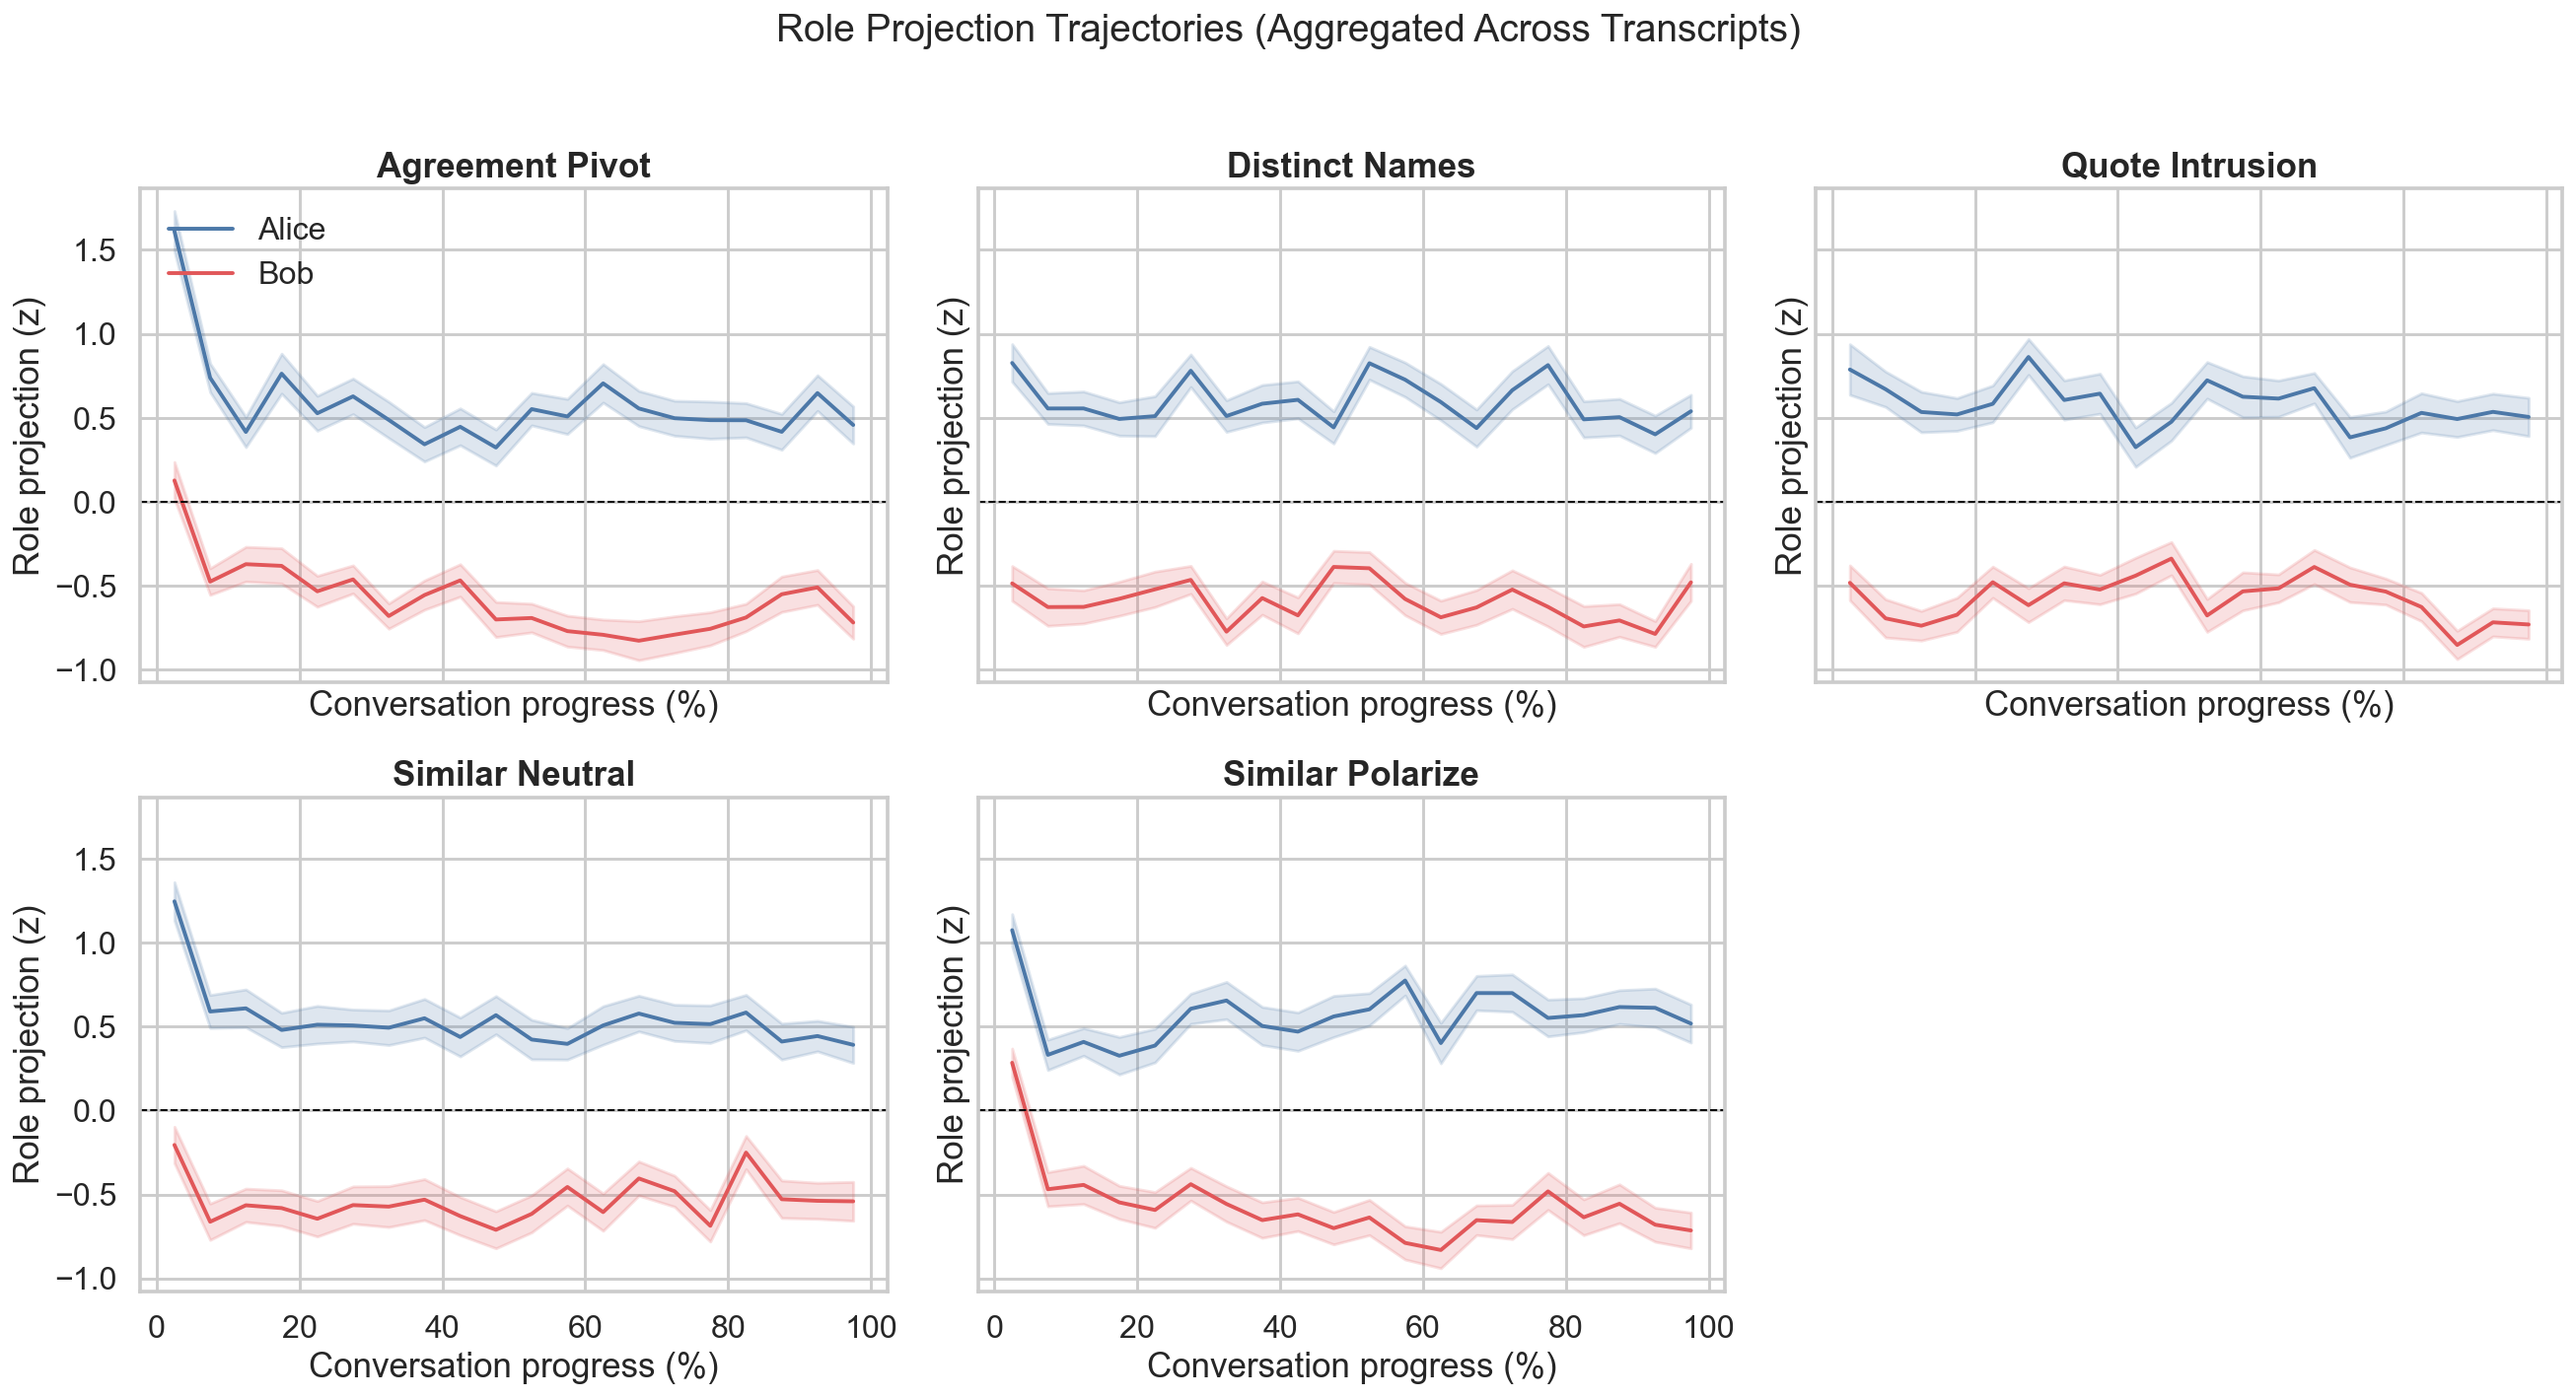

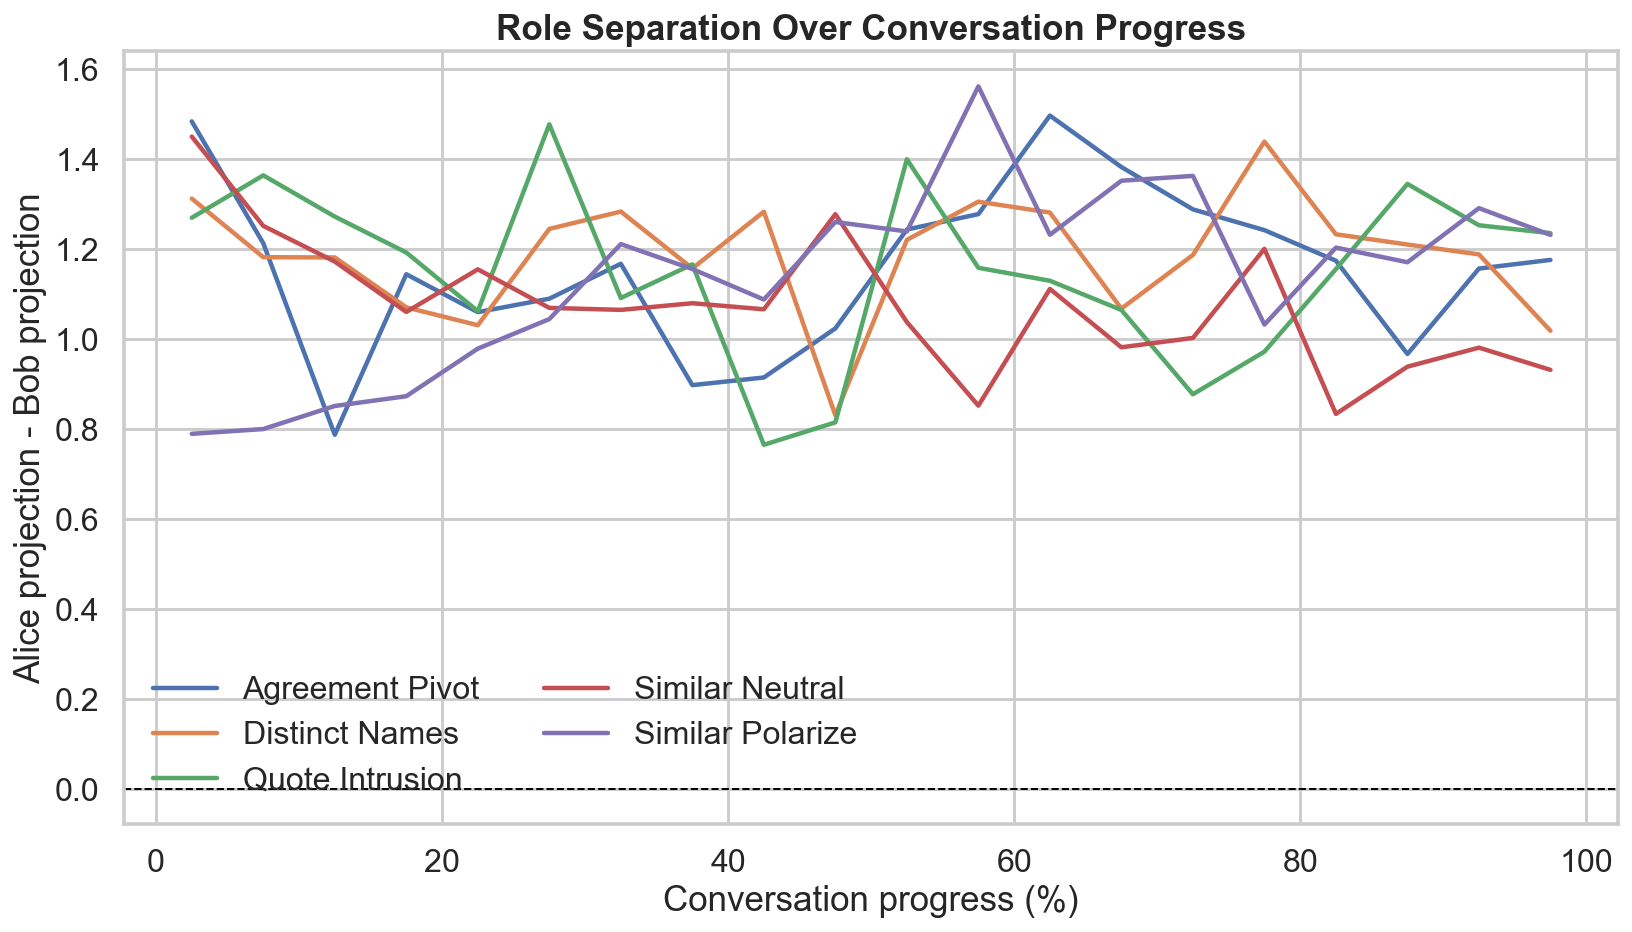

In [12]:
agg = (
    proj_df.groupby(["experiment", "speaker", "turn_bin"], as_index=False)
    .agg(
        proj_mean=("projection_z", "mean"),
        proj_std=("projection_z", "std"),
        n=("projection_z", "size"),
    )
)
agg["proj_sem"] = agg["proj_std"] / np.sqrt(np.maximum(1, agg["n"]))
agg["turn_pct"] = (agg["turn_bin"] + 0.5) / 20 * 100

fig, axes = plt.subplots(2, 3, figsize=(19, 10), sharex=True, sharey=True)
axes = axes.ravel()

for i, exp in enumerate(EXPERIMENT_ORDER):
    ax = axes[i]
    block = agg[agg["experiment"] == exp]
    for speaker, color in [("Alice", "#4C78A8"), ("Bob", "#E15759")]:
        cur = block[block["speaker"] == speaker]
        if cur.empty:
            continue
        x = cur["turn_pct"].to_numpy()
        y = cur["proj_mean"].to_numpy()
        sem = cur["proj_sem"].fillna(0.0).to_numpy()

        ax.plot(x, y, color=color, label=speaker, lw=2)
        ax.fill_between(x, y - sem, y + sem, color=color, alpha=0.18)

    ax.axhline(0.0, color="black", ls="--", lw=1)
    ax.set_title(DISPLAY_NAME[exp])
    ax.set_xlabel("Conversation progress (%)")
    ax.set_ylabel("Role projection (z)")

axes[-1].axis("off")
axes[0].legend(frameon=False, loc="upper left")

fig.suptitle("Role Projection Trajectories (Aggregated Across Transcripts)", y=1.02, fontsize=20)
fig.tight_layout()
fig.savefig(OUT_DIR / "figure3_projection_trajectories_grid.png", bbox_inches="tight")
fig.savefig(OUT_DIR / "figure3_projection_trajectories_grid.pdf", bbox_inches="tight")
plt.show()


pivot_sep = (
    agg.pivot_table(index=["experiment", "turn_bin", "turn_pct"], columns="speaker", values="proj_mean")
    .reset_index()
)
pivot_sep["role_gap"] = pivot_sep["Alice"] - pivot_sep["Bob"]

fig, ax = plt.subplots(figsize=(12, 7))
for exp in EXPERIMENT_ORDER:
    block = pivot_sep[pivot_sep["experiment"] == exp]
    ax.plot(
        block["turn_pct"],
        block["role_gap"],
        lw=2.3,
        label=DISPLAY_NAME[exp],
    )

ax.axhline(0.0, color="black", ls="--", lw=1)
ax.set_title("Role Separation Over Conversation Progress")
ax.set_xlabel("Conversation progress (%)")
ax.set_ylabel("Alice projection - Bob projection")
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
fig.savefig(OUT_DIR / "figure4_role_gap_over_turns.png", bbox_inches="tight")
fig.savefig(OUT_DIR / "figure4_role_gap_over_turns.pdf", bbox_inches="tight")
plt.show()

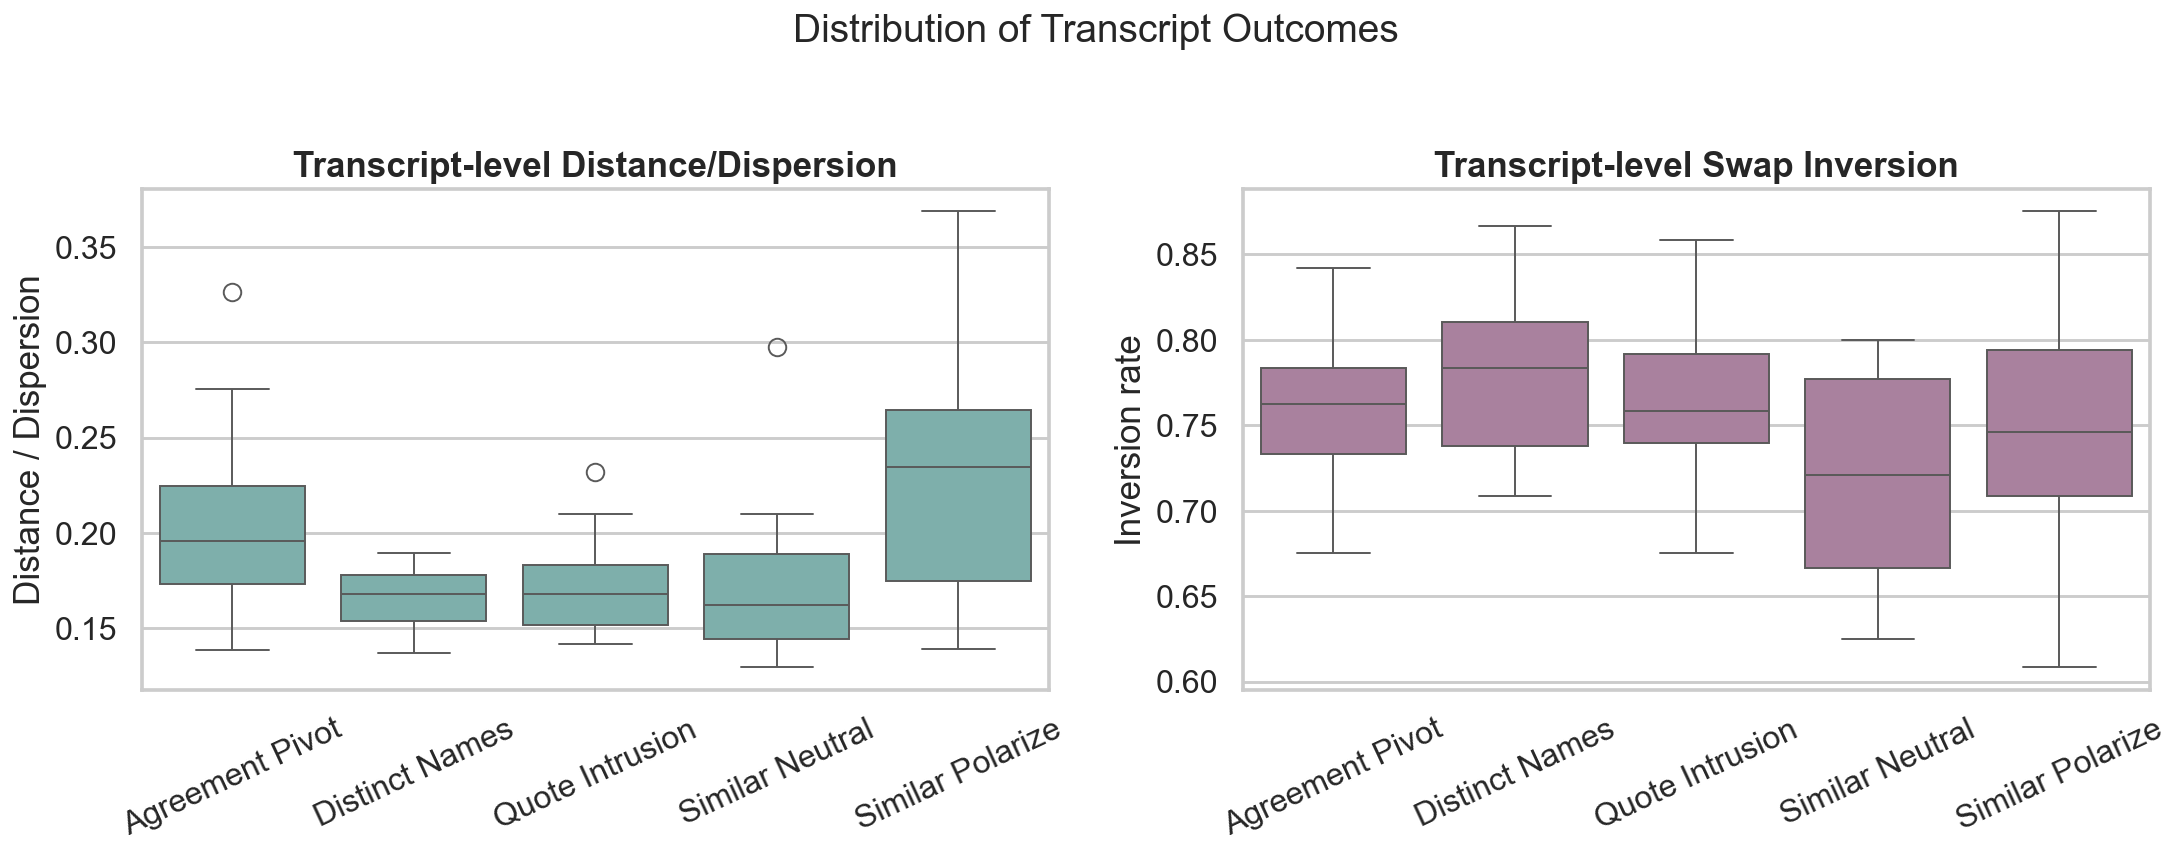

,experiment,distance_over_dispersion,silhouette_role_base_only,swap_projection_inversion_rate_label_centered,mean_transcript_direction_cosine,logreg_l2_mean,logreg_l2_selectivity_mean,linear_svm_mean,linear_svm_selectivity_mean
0,agreement_pivot,0.123953,0.003392,0.667500,0.364506,0.5,-0.002500,0.5,-0.002500
1,distinct_names,0.046718,0.000160,0.624583,0.043361,0.5,0.005167,0.5,0.003167
2,quote_intrusion,0.062295,0.000732,0.589167,0.108588,0.5,-0.001500,0.5,-0.002833
3,similar_neutral,0.062299,0.000555,0.582917,0.119677,0.5,0.001833,0.5,0.008167
4,similar_polarize,0.131934,0.003921,0.667917,0.298123,0.5,0.000500,0.5,0.000500


In [13]:
tx_plot = geom_tx_df.copy()
tx_plot["experiment_label"] = tx_plot["experiment"].map(DISPLAY_NAME)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=tx_plot,
    x="experiment_label",
    y="distance_over_dispersion",
    color="#76B7B2",
    ax=axes[0],
)
axes[0].set_title("Transcript-level Distance/Dispersion")
axes[0].set_xlabel("")
axes[0].set_ylabel("Distance / Dispersion")
axes[0].tick_params(axis="x", rotation=25)

sns.boxplot(
    data=tx_plot,
    x="experiment_label",
    y="swap_projection_inversion_rate_label_centered",
    color="#B07AA1",
    ax=axes[1],
)
axes[1].set_title("Transcript-level Swap Inversion")
axes[1].set_xlabel("")
axes[1].set_ylabel("Inversion rate")
axes[1].tick_params(axis="x", rotation=25)

fig.suptitle("Distribution of Transcript Outcomes", y=1.03, fontsize=20)
fig.tight_layout()
fig.savefig(OUT_DIR / "figure5_transcript_distributions.png", bbox_inches="tight")
fig.savefig(OUT_DIR / "figure5_transcript_distributions.pdf", bbox_inches="tight")
plt.show()


summary_cols = [
    "experiment",
    "distance_over_dispersion",
    "silhouette_role_base_only",
    "swap_projection_inversion_rate_label_centered",
    "mean_transcript_direction_cosine",
]
summary_table = geom_df[summary_cols].copy()
summary_table = summary_table.merge(
    probe_df[probe_df["task"] == "role"][[
        "experiment",
        "logreg_l2_mean",
        "logreg_l2_selectivity_mean",
        "linear_svm_mean",
        "linear_svm_selectivity_mean",
    ]],
    on="experiment",
    how="left",
)
summary_table = summary_table.sort_values("experiment", key=lambda s: s.map({e: i for i, e in enumerate(EXPERIMENT_ORDER)}))
summary_table.to_csv(OUT_DIR / "mean_pooling_summary_table.csv", index=False)
summary_table